In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_PATH = "/content/drive/MyDrive/ML_assignment"

print(os.listdir(BASE_PATH))

['chest_xray', 'bank_marketing']


In [4]:
BANK_PATH = "/content/drive/MyDrive/ML_assignment/bank_marketing"

print(os.listdir(BANK_PATH))

['bank-full.csv', '.DS_Store']


In [5]:
DATA_FILE = os.path.join(BANK_PATH, "bank-full.csv")

df = pd.read_csv(DATA_FILE, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (45211, 17)


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate rows: 0


In [8]:
print("Target distribution:")
print(df["y"].value_counts())

print("\nTarget distribution (%):")
print(df["y"].value_counts(normalize=True) * 100)

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target distribution (%):
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [9]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    unknown_count = (df[column] == "unknown").sum()

    if unknown_count > 0:
        print(f"{column}: {unknown_count} unknown values "
              f"({unknown_count / len(df) * 100:.2f}%)")

job: 288 unknown values (0.64%)
education: 1857 unknown values (4.11%)
contact: 13020 unknown values (28.80%)
poutcome: 36959 unknown values (81.75%)


In [10]:
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default:
default
no     44396
yes      815
Name: count, dtype: int64

housing:
housing
yes    25130
no     20081
Name: count, dtype: int64

loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

contact:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

In [11]:
X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (45211, 16)
Target shape: (45211,)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64


In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 36168
Test samples: 9043

Training target distribution:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Test target distribution:
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [15]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [16]:
logistic_model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [17]:
y_pred = logistic_model.predict(X_test)
y_pred_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"],
    digits=4
))

Accuracy : 0.8457
Precision: 0.4182
Recall   : 0.8147
F1-score : 0.5527
ROC-AUC  : 0.9079

Classification Report:

              precision    recall  f1-score   support

          No     0.9719    0.8498    0.9068      7985
         Yes     0.4182    0.8147    0.5527      1058

    accuracy                         0.8457      9043
   macro avg     0.6951    0.8323    0.7298      9043
weighted avg     0.9071    0.8457    0.8654      9043



Confusion Matrix:
[[6786 1199]
 [ 196  862]]


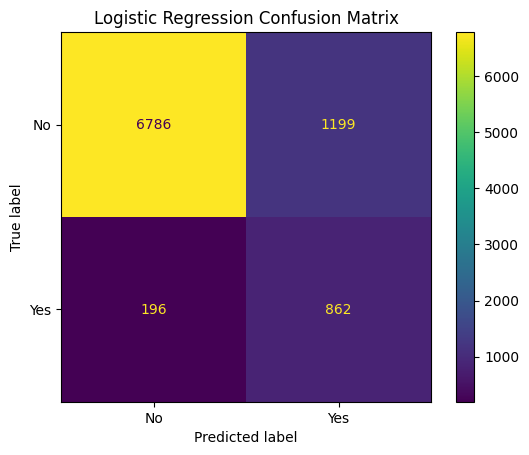

In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [20]:
# Get feature names after preprocessing
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort by absolute coefficient value
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_features = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
).head(15)

print("Top 15 influential features:")
print(top_features[["feature", "coefficient"]].to_string(index=False))

Top 15 influential features:
              feature  coefficient
cat__poutcome_success     1.824477
       cat__month_mar     1.722014
        num__duration     1.525751
       cat__month_jan    -1.302631
       cat__month_oct     1.276304
 cat__contact_unknown    -1.093252
       cat__month_jul    -1.067779
       cat__month_sep     0.984794
       cat__month_nov    -0.982664
       cat__month_aug    -0.902629
cat__poutcome_unknown    -0.786930
       cat__month_may    -0.725227
       cat__month_dec     0.713720
cat__poutcome_failure    -0.685477
     cat__job_student     0.657311
